# CatVTON basic front inference example

In [1]:
# Клонируем репозиторий CatVTON
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 17.67 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [2]:
# Устанавливаем зависимости из requirements.txt
!pip install -r requirements.txt

# Обновляем accelerate до последней версии (>=0.32.0) и ставим стабильный diffusers
!pip install -U accelerate diffusers==0.30.3 peft huggingface_hub

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-0l_f4rcm
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-0l_f4rcm
  Resolved https://github.com/huggingface/diffusers.git to commit c8eba433adf1f90d7fcc70092562ea50789ee8fb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 41.4 MB/s eta 0:00:00
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.38.0.dev0
    Uninstalling diffusers-0.38.0.dev0:
      Successfully uninstalled diffusers-0.38.0.dev0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.31.0
    Uninstalling accelerate-0.31.0:
      Successfully uninstalled accelerate-0.31.0


In [3]:
# Возвращаем стабильный PyTorch 2.4.0 и совместимый xformers (0.0.27.post2)
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install xformers==0.0.27.post2

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.7 MB/s eta 0:00:00
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.10.0+cu128
    Uninstalling torchaudio-2.10.0+cu128:
      Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 117.6 MB/s eta 0:00:00


In [1]:
import urllib.request

# test human-model image (front view)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/person/men/model_5.png",
    "person.png"
)

# test garment image
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Zheng-Chong/CatVTON/main/resource/demo/example/condition/upper/24083449_54173465_2048.jpg",
    "garment.jpg"
)

('garment.jpg', <http.client.HTTPMessage at 0x7a62a2370c80>)

In [3]:
%cd CatVTON

/content/CatVTON


In [4]:
%ls

app_flux.py  detectron2/  inference.py  preprocess_agnostic_mask.py  resource/
app_p2p.py   eval.py      LICENSE       __pycache__/                 utils.py
app.py       garment.jpg  model/        README.md
densepose/   index.html   person.png    requirements.txt


In [5]:
import torch
from PIL import Image
from huggingface_hub import snapshot_download

import os
import gc

# imports from CatVTON
from model.cloth_masker import AutoMasker
from model.pipeline import CatVTONPipeline

/usr/local/lib/python3.12/dist-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/usr/local/lib/python3.12/dist-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/xformers/__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/triton/__init__.py", line 8, in <module>
    from .runtime import (
  File "/usr/local/lib/python3.12/dist-packages/tri

0it [00:00, ?it/s]

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
from diffusers import AutoencoderKL
import torch

weight_dtype = torch.float16

base_model_path = "runwayml/stable-diffusion-inpainting"
catvton_model_path = "zhengchong/CatVTON"

pipeline = CatVTONPipeline(
    base_ckpt=base_model_path,
    attn_ckpt=catvton_model_path,
    attn_ckpt_version="mix",
    weight_dtype=weight_dtype,
    device=device,
    skip_safety_check=True
)

# Fix for the pink mask overlay and brown artifacts on T4:
# We use the official MSE-finetuned VAE which is safe in float16 and maintains high quality.
pipeline.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse", torch_dtype=weight_dtype).to(device)

# Built-in memory optimization
try:
    pipeline.enable_xformers_memory_efficient_attention()
    print("xformers optimization enabled.")
except Exception:
    print("Using built-in SDPA optimization.")

try:
    if hasattr(pipeline, "enable_model_cpu_offload"):
        pipeline.enable_model_cpu_offload()
        print("CPU offloading enabled!")
except Exception as e:
    print(f"Failed to enable CPU offloading: {e}")

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

dresscode-16k-512/attention/model.safete(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

flux-lora/pytorch_lora_weights.safetenso(…):   0%|          | 0.00/37.4M [00:00<?, ?B/s]

mix-48k-1024/attention/model.safetensors:   0%|          | 0.00/198M [00:00<?, ?B/s]

vitonhd-16k-512/attention/model.safetens(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

Downloaded zhengchong/CatVTON to /root/.cache/huggingface/hub/models--zhengchong--CatVTON/snapshots/2969fcf85fe62f2036605716f0b56f0b81d01d79
Using built-in SDPA optimization.


In [8]:
# Скачиваем основной репозиторий с весами (или берем из кэша)
repo_path = snapshot_download(repo_id="zhengchong/CatVTON")

# Инициализация модуля для автоматического создания масок с использованием путей внутри основного репозитория
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device=device
)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']


In [9]:
# Clear memory before running
torch.cuda.empty_cache()
gc.collect()

# 1. Load images
person_path = "/content/person.png"
garment_path = "/content/garment.jpg"

person_image = Image.open(person_path).convert("RGB")
garment_image = Image.open(garment_path).convert("RGB")

# Reduce resolution to 512x768 to avoid OOM on the free T4 GPU
target_size = (512, 768)
person_image = person_image.resize(target_size)
garment_image = garment_image.resize(target_size)

# 2. Generate mask
print("Generating mask...")
mask_result = automasker(person_image)
mask = mask_result['mask']

# 3. Clean up the patches (we are back to a standard KL VAE, so we need original functions)
import utils
import model.pipeline
import importlib

# Reloading restores the default CatVTON behavior that works with AutoencoderKL
importlib.reload(utils)
importlib.reload(model.pipeline)

# 4. Run inference
print("Running inference (try-on). This may take a couple of minutes...")
result_image = pipeline(
    image=person_image,
    condition_image=garment_image,
    mask=mask,
    num_inference_steps=50,
    guidance_scale=2.5
)[0]

Generating mask...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Running inference (try-on). This may take a couple of minutes...


100%|██████████| 50/50 [00:24<00:00,  2.02it/s]


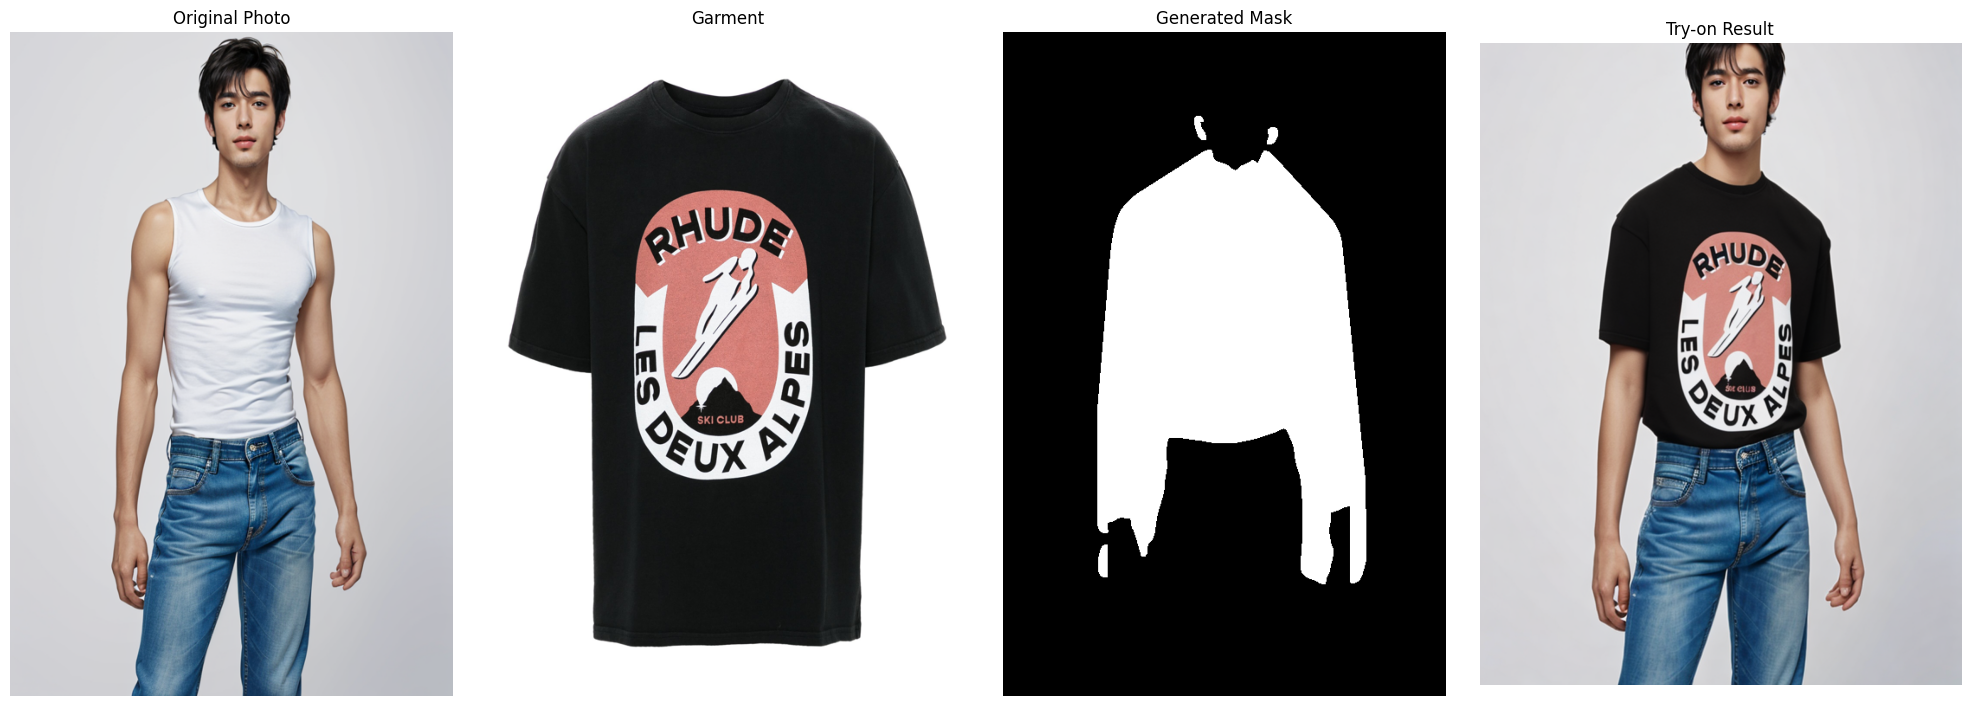

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 7))

axs[0].imshow(person_image)
axs[0].set_title("Original Photo")
axs[0].axis('off')

axs[1].imshow(garment_image)
axs[1].set_title("Garment")
axs[1].axis('off')

axs[2].imshow(mask, cmap='gray')
axs[2].set_title("Generated Mask")
axs[2].axis('off')

axs[3].imshow(result_image)
axs[3].set_title("Try-on Result")
axs[3].axis('off')

plt.tight_layout()
plt.show()

# Modifying the U-Net for Reference-Driven Editing (consistent side-view try-on generation)

In [14]:
import torch
from diffusers.models.attention_processor import Attention

class ReferenceAttentionProcessor:
    def __init__(self):
        self.reference_k = None
        self.reference_v = None
        self.is_reference_pass = False # Flag: generating reference (front) or target view?

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states=None,
        attention_mask=None,
        **kwargs,
    ):
        # 1. Get Q, K, V using built-in attention layers
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        # Transform dimensions for multi-head attention
        query = attn.head_to_batch_dim(query)
        key = attn.head_to_batch_dim(key)
        value = attn.head_to_batch_dim(value)

        # 2. Reference-Driven Editing Logic
        if self.is_reference_pass:
            # If this is the front view, just save K and V in the processor's memory
            self.reference_k = key.clone().detach()
            self.reference_v = value.clone().detach()
        else:
            # If this is a side/back view, APPEND the saved K and V from the front view
            if self.reference_k is not None and self.reference_v is not None:
                # Handle batch mismatch (due to Classifier-Free Guidance)
                ref_k = self.reference_k
                ref_v = self.reference_v
                if ref_k.shape[0] != key.shape[0]:
                    multiplier = key.shape[0] // ref_k.shape[0]
                    ref_k = ref_k.repeat(multiplier, 1, 1)
                    ref_v = ref_v.repeat(multiplier, 1, 1)

                # Concatenate along the spatial dimension (dim=2)
                key = torch.cat([ref_k, key], dim=2)
                value = torch.cat([ref_v, value], dim=2)

        # 3. Standard Attention computation
        attention_probs = attn.get_attention_scores(query, key, attention_mask)
        hidden_states = torch.bmm(attention_probs, value)
        hidden_states = attn.batch_to_head_dim(hidden_states)

        # Linear projections and dropout
        hidden_states = attn.to_out[0](hidden_states)
        if len(attn.to_out) > 1:
            hidden_states = attn.to_out[1](hidden_states)

        return hidden_states

# --- Integration into CatVTON pipeline ---

# 1. Create an instance of our processor
ref_attn_processor = ReferenceAttentionProcessor()

# 2. Replace standard attention layers in U-Net with our custom one.
attn_processors = {}
for name in pipeline.unet.attn_processors.keys():
    if "attn1" in name:
        attn_processors[name] = ref_attn_processor
    else:
        attn_processors[name] = pipeline.unet.attn_processors[name]

pipeline.unet.set_attn_processor(attn_processors)
print("Success: Custom Reference Attention Processor integrated into U-Net!")

Success: Custom Reference Attention Processor integrated into U-Net!


### Testing Reference-Driven Editing (View Consistency)

For this test, we use `person.png` as the front view (reference) and a new image `person_side.png` as the side view.
*Please make sure you have uploaded `person_side.png` to Colab before running the code below.*

In [12]:
import os
from PIL import Image
import torch

# Image paths
front_person_path = "/content/person.png"  # Already exists
side_person_path = "/content/person_side.png" # NEEDS TO BE UPLOADED!

# Check if side file exists
if not os.path.exists(side_person_path):
    print(f"File {side_person_path} not found! Please upload a side-view photo.")
else:
    print("Images found, preparing data...")

    # Load and resize
    target_size = (512, 768)
    front_person_img = Image.open(front_person_path).convert("RGB").resize(target_size)
    side_person_img = Image.open(side_person_path).convert("RGB").resize(target_size)

    # Generate masks using automasker
    print("Generating mask for front view...")
    front_mask = automasker(front_person_img)['mask']

    print("Generating mask for side view...")
    side_mask = automasker(side_person_img)['mask']

    # Use the same noise generator for stability
    generator = torch.Generator(device=device).manual_seed(42)

    print("\n--- PASS 1: Reference Generation (Front) ---")
    # Tell processor this is a reference pass (save features)
    ref_attn_processor.is_reference_pass = True
    front_result = pipeline(
        image=front_person_img,
        condition_image=garment_image,
        mask=front_mask,
        num_inference_steps=30,
        guidance_scale=2.5,
        generator=generator
    )[0]

    print("\n--- PASS 2: Target View Generation (Side) ---")
    # Tell processor to use saved features
    ref_attn_processor.is_reference_pass = False
    side_result = pipeline(
        image=side_person_img,
        condition_image=garment_image,
        mask=side_mask,
        num_inference_steps=30,
        guidance_scale=2.5,
        generator=generator
    )[0]
    print("\nGeneration completed!")

File /content/person_side.png not found! Please upload a side-view photo.


In [13]:
# Visualize results
if os.path.exists(side_person_path):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 3, figsize=(15, 6))

    axs[0].imshow(garment_image)
    axs[0].set_title("Garment (Condition)")
    axs[0].axis('off')

    axs[1].imshow(front_result)
    axs[1].set_title("Front Result (Reference)")
    axs[1].axis('off')

    axs[2].imshow(side_result)
    axs[2].set_title("Side Result (With feature injection)")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()